In [ ]:
# 1: if we can define the period very distinctlyi then that is going to be seasonality.
# 2: if we have some sort of trends that dont really seem to have any sort of repetition sometimes they go up sometimes they go down.
#    Many real world dataset are going to have this sort of behavior. Those are known cycles or cyclical behavior where we have trends
#    with no set repetition over a particular period.


In [ ]:
# The Hodrick-Prescott filter seperates a time series y_t into a trend component T_t and a cyclical component c_t. 
# => y_t = T_t + c_t

In [1]:
import numpy as np
import pandas as pd
%matplotlib inline

In [4]:
df = pd.read_csv("Data/macrodata.csv", index_col=0, parse_dates=True)

<pre><strong>US Macroeconomic Data for 1959Q1 - 2009Q3</strong>
Number of Observations - 203
Number of Variables - 14
Variable name definitions:
    year      - 1959q1 - 2009q3
    quarter   - 1-4
    realgdp   - Real gross domestic product (Bil. of chained 2005 US$,
                seasonally adjusted annual rate)
    realcons  - Real personal consumption expenditures (Bil. of chained
                2005 US$, seasonally adjusted annual rate)
    realinv   - Real gross private domestic investment (Bil. of chained
                2005 US$, seasonally adjusted annual rate)
    realgovt  - Real federal consumption expenditures & gross investment
                (Bil. of chained 2005 US$, seasonally adjusted annual rate)
    realdpi   - Real private disposable income (Bil. of chained 2005
                US$, seasonally adjusted annual rate)
    cpi       - End of the quarter consumer price index for all urban
                consumers: all items (1982-84 = 100, seasonally adjusted).
    m1        - End of the quarter M1 nominal money stock (Seasonally
                adjusted)
    tbilrate  - Quarterly monthly average of the monthly 3-month
                treasury bill: secondary market rate
    unemp     - Seasonally adjusted unemployment rate (%)
    pop       - End of the quarter total population: all ages incl. armed
                forces over seas
    infl      - Inflation rate (ln(cpi_{t}/cpi_{t-1}) * 400)
    realint   - Real interest rate (tbilrate - infl)</pre>

In [5]:
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959-03-31,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


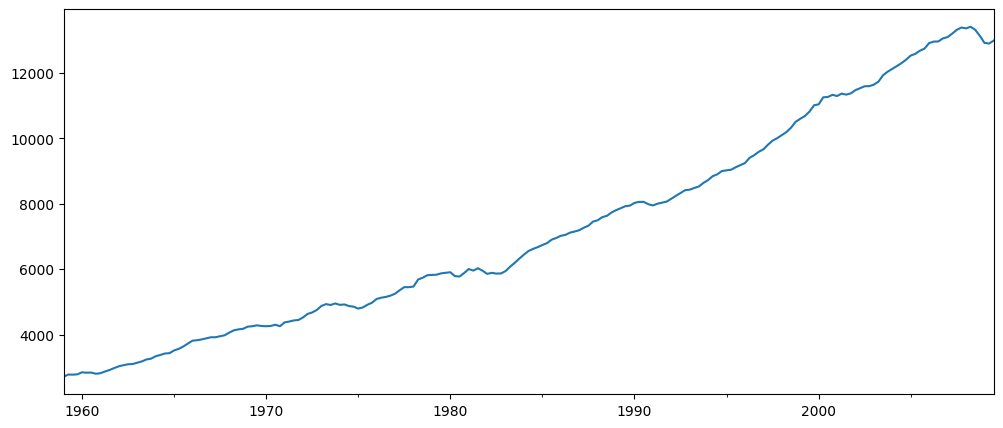

In [11]:
df["realgdp"].plot(figsize=(12, 5));

#### Introduction to Statmodels Library

In [10]:
# !pip install statsmodels
from statsmodels.tsa.filters.hp_filter import hpfilter

In [15]:
# The Hodrick-Prescott filter
# It has two parameters,
#  - one of them is X so called dataset,
#  - second one lambda refers what the actual frequency of your data is.
# And returns a tuple that includes cyclical component and trend component.

gdp_cycle, gdp_trend = hpfilter(df["realgdp"], lamb=1600)

In [16]:
type(gdp_cycle)

pandas.core.series.Series

In [17]:
type(gdp_trend)

pandas.core.series.Series

<Axes: >

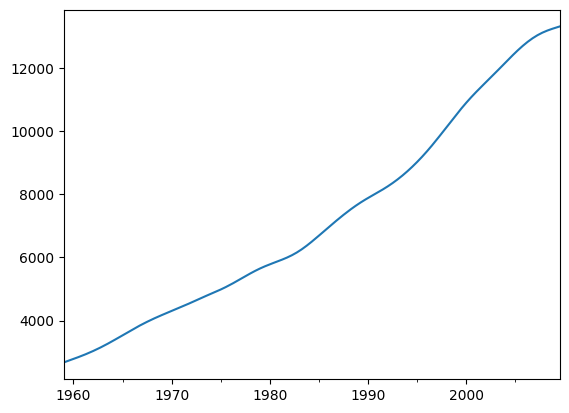

In [18]:
gdp_trend.plot()

In [19]:
df["trend"] = gdp_trend

In [20]:
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,trend
1959-03-31,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00,2670.837085
1959-06-30,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,2698.712468
1959-09-30,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,2726.612545
1959-12-31,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,2754.612067
1960-03-31,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,2782.816333


<Axes: >

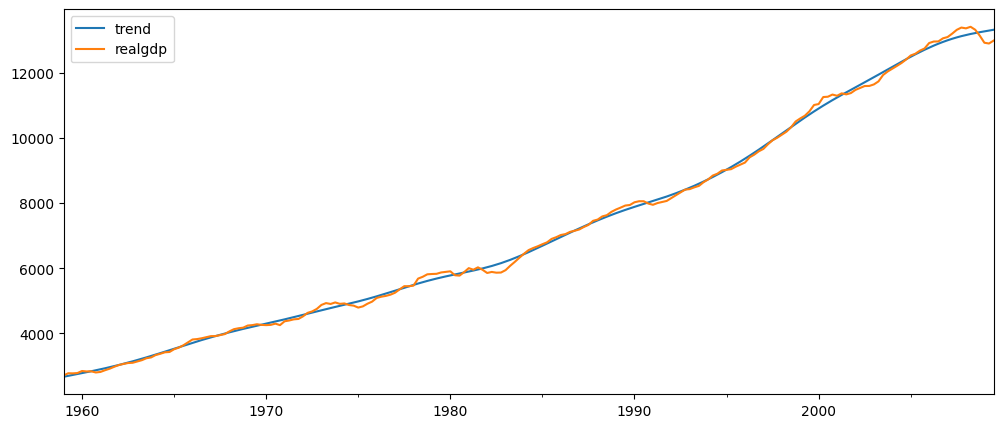

In [22]:
df[["trend", "realgdp"]].plot(figsize=(12, 5))

<Axes: >

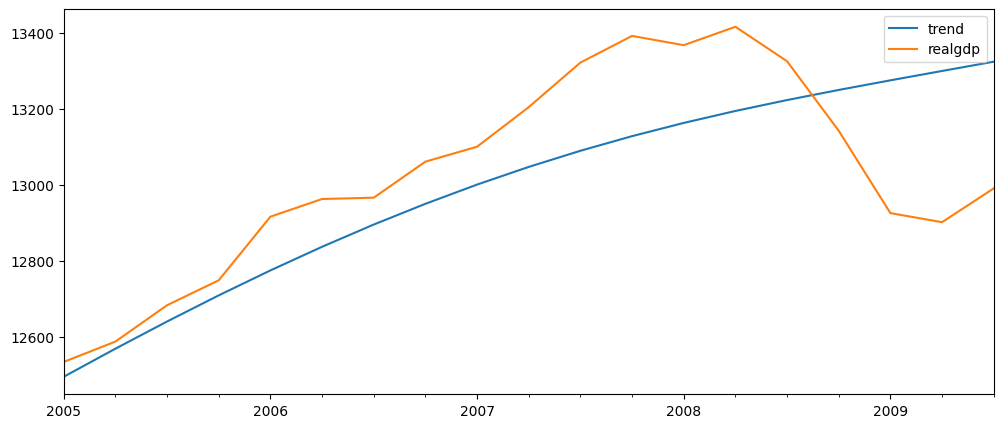

In [23]:
df[["trend", "realgdp"]]["2005-01-01":].plot(figsize=(12, 5))

#### ETS Decomposition

In [13]:
# ETS Models
# ETS: Error - Trend - Seasonality

# When performing an ETS decomposition, there is two types of main ETS models.

# 1: Additive Model, trend is more linear and seasonality and trend components seems to be constant over time
# (e.g. every year we add 10.000 passengers)

# 2: Multiplicative Model is more appropriate when we are increasing or decreasing at a non-linear rate
# (e.g. each year we double the amount of passengers.)

In [14]:
import pandas as pd

df_airline = pd.read_csv("Data/airline_passengers.csv", index_col="Month", parse_dates=True)

df_airline

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [18]:
df_airline = df_airline.dropna()

df_airline.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<Axes: xlabel='Month'>

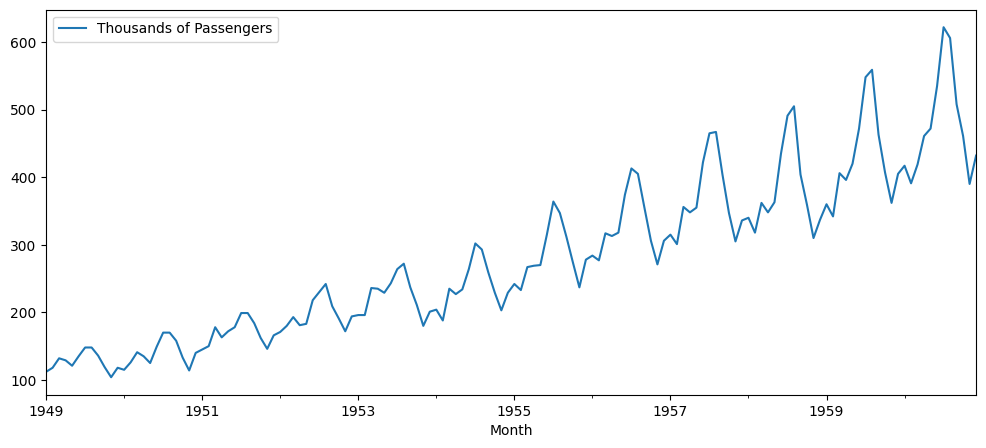

In [19]:
df_airline.plot(figsize=(12, 5))

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [26]:
result = seasonal_decompose(df_airline["Thousands of Passengers"], model="multiplicative")

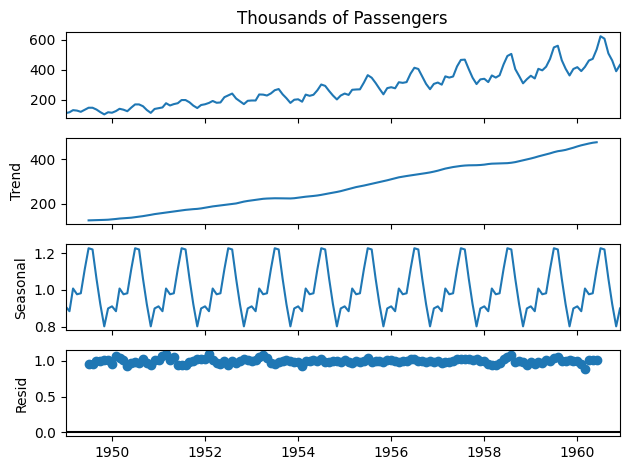

In [32]:
result.plot();

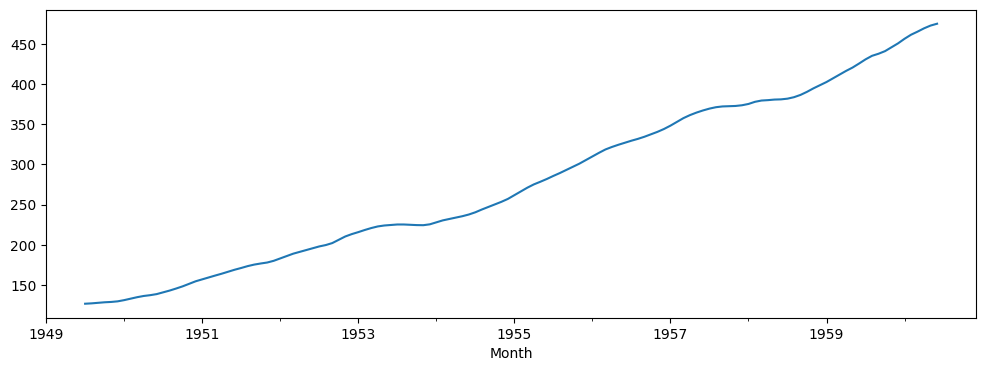

In [35]:
result.trend.plot(figsize=(12,4));

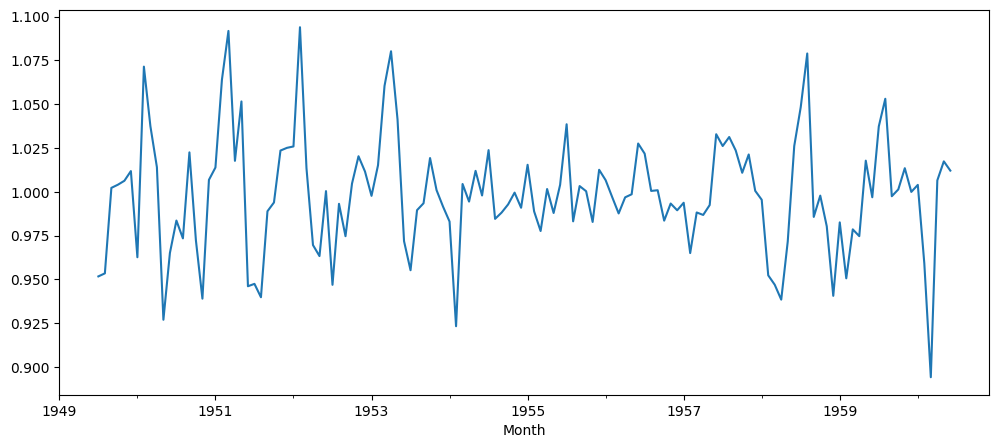

In [37]:
result.resid.plot(figsize=(12,5));

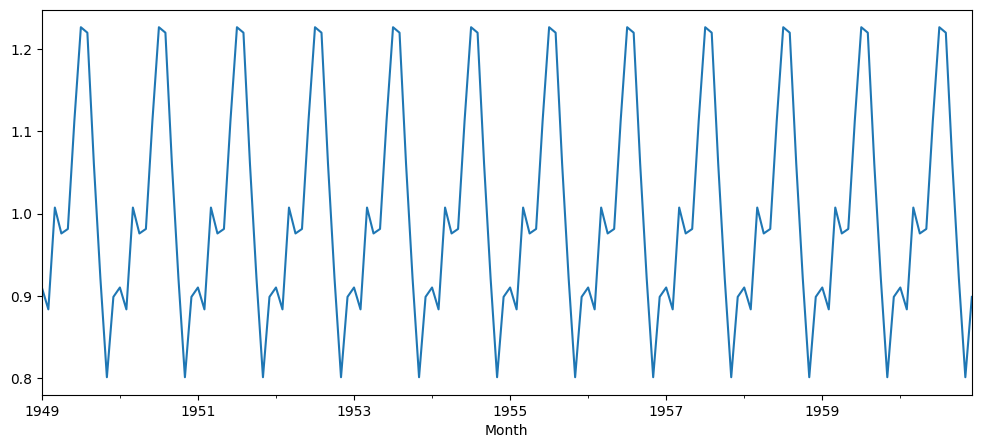

In [38]:
result.seasonal.plot(figsize=(12,5));

#### EWMA Model

In [36]:
# Exponentially Weighted Moving Average

In [ ]:
# notice: fark etme, dikkat, uyarı 
# decomposition: ayrıştırma
# residual: rizicuıl: artık, kalan
